<a href="https://colab.research.google.com/github/7amzaGH/TUBLEX-Bubble-Plume-Analysis/blob/main/notebooks/02_TUBLEX_XGBoost_Baseline_Training_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUBLEX XGBoost Training and Explainable Evaluation

**Repository:** [TUBLEX-Bubble-Plume-Analysis](https://github.com/7amzaGH/TUBLEX-Bubble-Plume-Analysis)

This notebook trains and evaluates a Xgboost classifier for underwater gas leak indication using the TUBLEX bubble plume descriptor dataset.

The notebook includes:

- dataset loading
- video-level train/test split
- Random Forest ablation study
- final model evaluation
- confusion matrix, ROC curve, and precision-recall curve
- feature importance
- SHAP explainability
- failure analysis for difficult samples

Only the 11 TUBLEX bubble descriptor features are used for training. Experimental metadata such as gauge, pressure, condition ID, and data group are used only for reporting and leakage checking.

XGBoost is included as a strong baseline model for comparison with the selected Random Forest deployment model. The notebook uses the public repository structure, saves outputs into `results/xgboost_baseline/`, and saves the trained model and metadata into `models/xgboost/` when that folder exists.


In [1]:
# ============================================================
# Clone the TUBLEX GitHub repository
# ============================================================

from pathlib import Path
import os
import subprocess

REPO_URL = "https://github.com/7amzaGH/TUBLEX-Bubble-Plume-Analysis.git"
REPO_NAME = "TUBLEX-Bubble-Plume-Analysis"

# In Colab or a fresh environment, clone the repository.
# If the notebook is already running from inside the repo, this cell does nothing.
if not Path("data").exists():
    if not Path(REPO_NAME).exists():
        subprocess.run(["git", "clone", REPO_URL], check=True)

    os.chdir(REPO_NAME)

print("Current working directory:", Path.cwd())
print("Repository ready:", Path("data").exists())


Current working directory: /content/TUBLEX-Bubble-Plume-Analysis
Repository ready: True


In [2]:
# ============================================================
# Install repository requirements
# ============================================================

import sys
import subprocess
from pathlib import Path

requirements_path = Path("requirements.txt")

if requirements_path.exists():
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "-r",
        str(requirements_path),
    ])
else:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "numpy",
        "pandas",
        "matplotlib",
        "scikit-learn",
        "xgboost",
        "shap",
        "joblib",
    ])

print("Dependencies installed.")


Dependencies installed.


In [3]:
# ============================================================
# Import libraries and define reproducible paths
# ============================================================

import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd()

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "tublex_window_features.csv"
METADATA_PATH = PROJECT_ROOT / "data" / "metadata" / "tublex_video_metadata.csv"
SPLIT_PATH = PROJECT_ROOT / "data" / "splits" / "tublex_video_level_split_seed42.csv"

OUTPUT_DIR = PROJECT_ROOT / "results" / "xgboost_baseline"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
SHAP_DIR = OUTPUT_DIR / "shap"

# Preferred clean model path.
MODEL_DIR = PROJECT_ROOT / "models" / "xgboost"

# Backward-compatible fallback for older folder naming.
legacy_model_dir = PROJECT_ROOT / "models" / "Xgboost_tublex"
if not MODEL_DIR.exists() and legacy_model_dir.exists():
    MODEL_DIR = legacy_model_dir

for folder in [OUTPUT_DIR, TABLE_DIR, FIGURE_DIR, SHAP_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

XGB_PARAMS = {
    "n_estimators": 200,
    "max_depth": 3,
    "learning_rate": 0.05,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

print("Project root:", PROJECT_ROOT.resolve())
print("Dataset:", DATA_PATH)
print("Metadata:", METADATA_PATH)
print("Split:", SPLIT_PATH)
print("Tables:", TABLE_DIR)
print("Figures:", FIGURE_DIR)
print("SHAP:", SHAP_DIR)
print("Model directory:", MODEL_DIR)


Project root: /content/TUBLEX-Bubble-Plume-Analysis
Dataset: /content/TUBLEX-Bubble-Plume-Analysis/data/processed/tublex_window_features.csv
Metadata: /content/TUBLEX-Bubble-Plume-Analysis/data/metadata/tublex_video_metadata.csv
Split: /content/TUBLEX-Bubble-Plume-Analysis/data/splits/tublex_video_level_split_seed42.csv
Tables: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/tables
Figures: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/figures
SHAP: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/shap
Model directory: /content/TUBLEX-Bubble-Plume-Analysis/models/xgboost


In [4]:
# ============================================================
# Load dataset
# ============================================================

df = pd.read_csv(DATA_PATH)
metadata = pd.read_csv(METADATA_PATH)

print("=" * 70)
print("TUBLEX DATASET SUMMARY")
print("=" * 70)

print("Dataset shape:", df.shape)
print("Metadata shape:", metadata.shape)

print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nUnique source videos:", df["source_video_id"].nunique())


TUBLEX DATASET SUMMARY
Dataset shape: (2504, 15)
Metadata shape: (85, 8)

Label distribution:
label
0    1252
1    1252
Name: count, dtype: int64

Unique source videos: 85


In [5]:
# ============================================================
# Define TUBLEX feature groups
# ============================================================

DENSITY_FEATURES = [
    "mean_bubble_count",
    "max_bubble_count",
]

STABILITY_FEATURES = [
    "std_bubble_count",
    "temporal_variance",
    "leak_evolution",
]

GEOMETRY_FEATURES = [
    "continuity_ratio",
    "mean_vertical_chain",
]

TEMPORAL_HISTORY_FEATURES = [
    "prev3_mean_bubble_count",
    "prev3_std_bubble_count",
    "prev3_continuity_ratio",
    "prev3_mean_vertical_chain",
]

ALL_FEATURES = (
    DENSITY_FEATURES
    + STABILITY_FEATURES
    + GEOMETRY_FEATURES
    + TEMPORAL_HISTORY_FEATURES
)

TARGET = "label"

FORBIDDEN_FEATURES = [
    "sample_id",
    "source_video_id",
    "window_id",
    "time_sec",
    "window_start_time",
    "window_end_time",
    "condition_id",
    "data_group",
    "g",
    "psi",
]

for col in ALL_FEATURES:
    assert col in df.columns, f"Missing feature: {col}"

assert len(set(ALL_FEATURES).intersection(FORBIDDEN_FEATURES)) == 0

print("TUBLEX model features:")
for i, feature in enumerate(ALL_FEATURES, start=1):
    print(f"{i:02d}. {feature}")

print("\nNo metadata columns are used as model features.")


TUBLEX model features:
01. mean_bubble_count
02. max_bubble_count
03. std_bubble_count
04. temporal_variance
05. leak_evolution
06. continuity_ratio
07. mean_vertical_chain
08. prev3_mean_bubble_count
09. prev3_std_bubble_count
10. prev3_continuity_ratio
11. prev3_mean_vertical_chain

No metadata columns are used as model features.


In [6]:
# ============================================================
# Apply video-level train/test split
# ============================================================

if SPLIT_PATH.exists():
    split_df = pd.read_csv(SPLIT_PATH)
    print("Loaded existing split:", SPLIT_PATH)

else:
    print("Creating new video-level split with seed 42.")

    splitter = GroupShuffleSplit(
        n_splits=1,
        train_size=0.8,
        random_state=RANDOM_STATE,
    )

    X_temp = df[ALL_FEATURES]
    y_temp = df[TARGET]
    groups_temp = df["source_video_id"]

    train_idx_temp, test_idx_temp = next(splitter.split(X_temp, y_temp, groups_temp))

    train_videos_temp = set(df.iloc[train_idx_temp]["source_video_id"])
    test_videos_temp = set(df.iloc[test_idx_temp]["source_video_id"])

    split_df = pd.DataFrame({
        "source_video_id": sorted(df["source_video_id"].unique())
    })

    split_df["split"] = split_df["source_video_id"].apply(
        lambda x: "train" if x in train_videos_temp else "test"
    )

    SPLIT_PATH.parent.mkdir(parents=True, exist_ok=True)
    split_df.to_csv(SPLIT_PATH, index=False)

    print("Saved split:", SPLIT_PATH)

train_videos = set(split_df.loc[split_df["split"] == "train", "source_video_id"])
test_videos = set(split_df.loc[split_df["split"] == "test", "source_video_id"])

assert train_videos.isdisjoint(test_videos)
assert train_videos.union(test_videos) == set(df["source_video_id"].unique())

train_mask = df["source_video_id"].isin(train_videos)
test_mask = df["source_video_id"].isin(test_videos)

X_train = df.loc[train_mask, ALL_FEATURES]
X_test = df.loc[test_mask, ALL_FEATURES]

y_train = df.loc[train_mask, TARGET]
y_test = df.loc[test_mask, TARGET]

groups_train = df.loc[train_mask, "source_video_id"]

split_summary = pd.DataFrame({
    "Split": ["Train", "Test"],
    "Windows": [len(X_train), len(X_test)],
    "Videos": [len(train_videos), len(test_videos)],
    "Leak": [int((y_train == 1).sum()), int((y_test == 1).sum())],
    "Non-Leak": [int((y_train == 0).sum()), int((y_test == 0).sum())],
})

split_summary.to_csv(TABLE_DIR / "video_level_split_summary.csv", index=False)

display(split_summary)


Loaded existing split: /content/TUBLEX-Bubble-Plume-Analysis/data/splits/tublex_video_level_split_seed42.csv


,Split,Windows,Videos,Leak,Non-Leak
0,Train,2009,68,999,1010
1,Test,495,17,253,242


In [7]:
# ============================================================
# Define ablation experiments
# ============================================================

experiments = {
    "E1: Naive Mean Count": ["mean_bubble_count"],
    "E2: Density Only": DENSITY_FEATURES,
    "E3: E2 + Stability": DENSITY_FEATURES + STABILITY_FEATURES,
    "E4: E3 + Geometry": DENSITY_FEATURES + STABILITY_FEATURES + GEOMETRY_FEATURES,
    "E5: Full TUBLEX": ALL_FEATURES,
}

experiment_table = pd.DataFrame({
    "Experiment": list(experiments.keys()),
    "N Features": [len(v) for v in experiments.values()],
    "Features": [", ".join(v) for v in experiments.values()],
})

experiment_table.to_csv(TABLE_DIR / "ablation_experiment_definitions.csv", index=False)

display(experiment_table)


,Experiment,N Features,Features
0,E1: Naive Mean Count,1,mean_bubble_count
1,E2: Density Only,2,"mean_bubble_count, max_bubble_count"
2,E3: E2 + Stability,5,"mean_bubble_count, max_bubble_count, std_bubbl..."
3,E4: E3 + Geometry,7,"mean_bubble_count, max_bubble_count, std_bubbl..."
4,E5: Full TUBLEX,11,"mean_bubble_count, max_bubble_count, std_bubbl..."


In [8]:
# ============================================================
# Run XGBoost ablation study
# ============================================================

gkf = GroupKFold(n_splits=5)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

ablation_results = []

print("=" * 70)
print("RUNNING XGBOOST ABLATION STUDY")
print("=" * 70)

for exp_name, feature_cols in experiments.items():

    model = XGBClassifier(**XGB_PARAMS)

    cv_results = cross_validate(
        model,
        X_train[feature_cols],
        y_train,
        groups=groups_train,
        cv=gkf,
        scoring=scoring,
        n_jobs=-1,
    )

    model.fit(X_train[feature_cols], y_train)

    pred = model.predict(X_test[feature_cols])
    prob = model.predict_proba(X_test[feature_cols])[:, 1]

    row = {
        "Experiment": exp_name,
        "N Features": len(feature_cols),
        "CV Accuracy": cv_results["test_accuracy"].mean(),
        "CV F1": cv_results["test_f1"].mean(),
        "CV F1 Std": cv_results["test_f1"].std(),
        "CV ROC-AUC": cv_results["test_roc_auc"].mean(),
        "Test Accuracy": accuracy_score(y_test, pred),
        "Test Precision": precision_score(y_test, pred),
        "Test Recall": recall_score(y_test, pred),
        "Test F1": f1_score(y_test, pred),
        "Test ROC-AUC": roc_auc_score(y_test, prob),
        "Test PR-AUC": average_precision_score(y_test, prob),
    }

    ablation_results.append(row)

    print(f"\n{exp_name}")
    print(f"Features: {len(feature_cols)}")
    print(f"CV F1:   {row['CV F1']:.4f} ± {row['CV F1 Std']:.4f}")
    print(f"Test F1: {row['Test F1']:.4f}")
    print(f"ROC-AUC: {row['Test ROC-AUC']:.4f}")

ablation_df = pd.DataFrame(ablation_results)

ablation_display = ablation_df.copy()
metric_cols = [c for c in ablation_display.columns if c not in ["Experiment", "N Features"]]
ablation_display[metric_cols] = ablation_display[metric_cols].round(4)

ablation_path = TABLE_DIR / "xgboost_ablation_results.csv"
ablation_display.to_csv(ablation_path, index=False)

display(ablation_display)

print("Saved:", ablation_path)


RUNNING XGBOOST ABLATION STUDY

E1: Naive Mean Count
Features: 1
CV F1:   0.8301 ± 0.1073
Test F1: 0.9047
ROC-AUC: 0.8369

E2: Density Only
Features: 2
CV F1:   0.8488 ± 0.1145
Test F1: 0.8298
ROC-AUC: 0.8037

E3: E2 + Stability
Features: 5
CV F1:   0.9881 ± 0.0058
Test F1: 0.9901
ROC-AUC: 0.9998

E4: E3 + Geometry
Features: 7
CV F1:   0.9888 ± 0.0048
Test F1: 0.9880
ROC-AUC: 0.9998

E5: Full TUBLEX
Features: 11
CV F1:   0.9921 ± 0.0053
Test F1: 0.9860
ROC-AUC: 0.9998


,Experiment,N Features,CV Accuracy,CV F1,CV F1 Std,CV ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC,Test PR-AUC
0,E1: Naive Mean Count,1,0.8185,0.8301,0.1073,0.8104,0.8970,0.8582,0.9565,0.9047,0.8369,0.7015
1,E2: Density Only,2,0.8370,0.8488,0.1145,0.8317,0.7919,0.7131,0.9921,0.8298,0.8037,0.6676
2,E3: E2 + Stability,5,0.9876,0.9881,0.0058,0.9986,0.9899,0.9960,0.9842,0.9901,0.9998,0.9998
3,E4: E3 + Geometry,7,0.9886,0.9888,0.0048,0.9990,0.9879,0.9960,0.9802,0.9880,0.9998,0.9998
4,E5: Full TUBLEX,11,0.9916,0.9921,0.0053,0.9993,0.9859,0.9960,0.9763,0.9860,0.9998,0.9998


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/tables/xgboost_ablation_results.csv


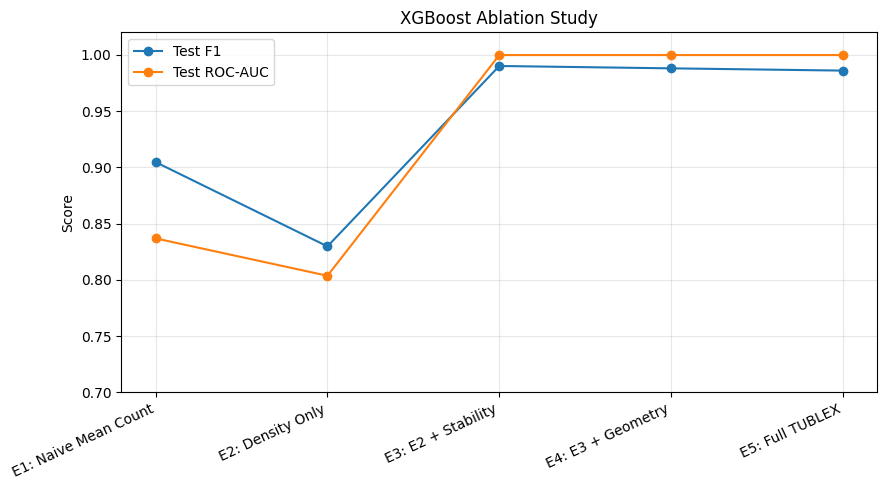

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/figures/xgboost_ablation_results.png


In [9]:
# ============================================================
# Plot XGBoost ablation results
# ============================================================

plot_df = ablation_display.copy()

plt.figure(figsize=(9, 5))

plt.plot(plot_df["Experiment"], plot_df["Test F1"], marker="o", label="Test F1")
plt.plot(plot_df["Experiment"], plot_df["Test ROC-AUC"], marker="o", label="Test ROC-AUC")

plt.xticks(rotation=25, ha="right")
plt.ylim(0.70, 1.02)
plt.ylabel("Score")
plt.title("XGBoost Ablation Study")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

fig_path = FIGURE_DIR / "xgboost_ablation_results.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [10]:
# ============================================================
# Train final XGBoost baseline
# ============================================================

final_xgb = XGBClassifier(**XGB_PARAMS)

final_xgb.fit(X_train[ALL_FEATURES], y_train)

y_pred = final_xgb.predict(X_test[ALL_FEATURES])
y_prob = final_xgb.predict_proba(X_test[ALL_FEATURES])[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob),
    "PR-AUC": average_precision_score(y_test, y_prob),
}

final_metrics_df = pd.DataFrame({
    "Metric": list(final_metrics.keys()),
    "Value": list(final_metrics.values()),
})

final_metrics_df["Value"] = final_metrics_df["Value"].round(4)

final_metrics_path = TABLE_DIR / "xgboost_final_metrics.csv"
final_metrics_df.to_csv(final_metrics_path, index=False)

display(final_metrics_df)

print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=["Non-Leak", "Leak"]))

print("Saved:", final_metrics_path)


,Metric,Value
0,Accuracy,0.9859
1,Precision,0.9960
2,Recall,0.9763
3,F1,0.9860
4,ROC-AUC,0.9998
5,PR-AUC,0.9998



Classification report:
              precision    recall  f1-score   support

    Non-Leak       0.98      1.00      0.99       242
        Leak       1.00      0.98      0.99       253

    accuracy                           0.99       495
   macro avg       0.99      0.99      0.99       495
weighted avg       0.99      0.99      0.99       495

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/tables/xgboost_final_metrics.csv


In [11]:
# ============================================================
# Save XGBoost model, metadata, and test predictions
# ============================================================

model_path = MODEL_DIR / "xgb_tublex_final.joblib"
metadata_path = MODEL_DIR / "xgb_tublex_metadata.json"
prediction_path = TABLE_DIR / "xgboost_test_predictions.csv"

joblib.dump(final_xgb, model_path)

model_metadata = {
    "model_name": "TUBLEX XGBoost Baseline",
    "model_type": "XGBClassifier",
    "positive_class": 1,
    "decision_threshold": 0.5,
    "feature_columns": list(ALL_FEATURES),
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=2)

prediction_columns = [
    "sample_id",
    "source_video_id",
    "window_id",
    "time_sec",
    "label",
]
prediction_columns = [c for c in prediction_columns if c in df.columns]

predictions_df = df.loc[test_mask, prediction_columns].copy()
predictions_df["predicted_label"] = y_pred
predictions_df["leak_probability"] = y_prob

predictions_df = predictions_df.merge(metadata, on="source_video_id", how="left")
predictions_df.to_csv(prediction_path, index=False)

print("Saved model:", model_path)
print("Saved metadata:", metadata_path)
print("Saved predictions:", prediction_path)

display(predictions_df.head())


Saved model: /content/TUBLEX-Bubble-Plume-Analysis/models/xgboost/xgb_tublex_final.joblib
Saved metadata: /content/TUBLEX-Bubble-Plume-Analysis/models/xgboost/xgb_tublex_metadata.json
Saved predictions: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/tables/xgboost_test_predictions.csv


,sample_id,source_video_id,window_id,label,predicted_label,leak_probability,condition_id,data_group,g,psi,n_windows,n_label_0,n_label_1
0,L_G12_PSI05_V001_W0000,L_G12_PSI05_V001,0,0,0,0.000543,G12_PSI05,leak,12,5,40,8,32
1,L_G12_PSI05_V001_W0001,L_G12_PSI05_V001,1,0,0,0.002179,G12_PSI05,leak,12,5,40,8,32
2,L_G12_PSI05_V001_W0002,L_G12_PSI05_V001,2,0,0,0.000765,G12_PSI05,leak,12,5,40,8,32
3,L_G12_PSI05_V001_W0003,L_G12_PSI05_V001,3,0,0,0.000782,G12_PSI05,leak,12,5,40,8,32
4,L_G12_PSI05_V001_W0004,L_G12_PSI05_V001,4,0,0,0.000679,G12_PSI05,leak,12,5,40,8,32


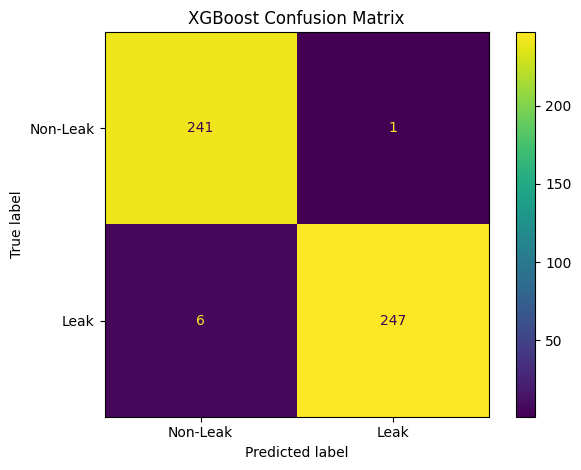

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/figures/xgboost_confusion_matrix.png
[[241   1]
 [  6 247]]


In [12]:
# ============================================================
# Plot XGBoost confusion matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Leak", "Leak"],
)

disp.plot(values_format="d")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()

fig_path = FIGURE_DIR / "xgboost_confusion_matrix.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)
print(cm)


In [15]:
# ============================================================
# Export XGBoost feature importance table
# ============================================================

importance_df = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Importance": final_xgb.feature_importances_,
}).sort_values("Importance", ascending=False)

importance_df["Importance"] = importance_df["Importance"].round(6)

importance_path = TABLE_DIR / "xgboost_feature_importance.csv"
importance_df.to_csv(importance_path, index=False)

display(importance_df)

print("Saved:", importance_path)


,Feature,Importance
3,temporal_variance,0.447655
2,std_bubble_count,0.434226
6,mean_vertical_chain,0.037720
10,prev3_mean_vertical_chain,0.026237
1,max_bubble_count,0.014083
0,mean_bubble_count,0.013247
5,continuity_ratio,0.006606
7,prev3_mean_bubble_count,0.005661
8,prev3_std_bubble_count,0.005178
9,prev3_continuity_ratio,0.005163


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/tables/xgboost_feature_importance.csv


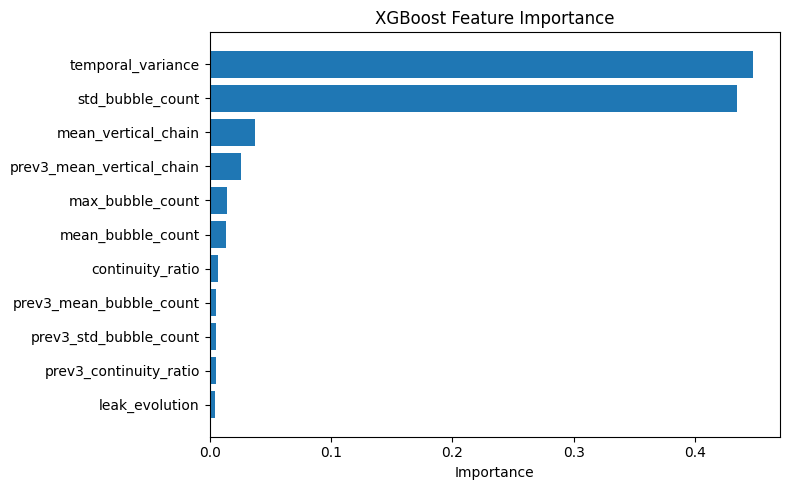

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/figures/xgboost_feature_importance.png


In [16]:
# ============================================================
# Plot XGBoost feature importance
# ============================================================

plot_df = importance_df.sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(plot_df["Feature"], plot_df["Importance"])

plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.tight_layout()

fig_path = FIGURE_DIR / "xgboost_feature_importance.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [17]:
# ============================================================
# Set up SHAP explainability
# ============================================================

try:
    import shap
except ImportError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

from IPython.display import display, HTML

shap.initjs()

print("SHAP version:", shap.__version__)


SHAP version: 0.52.0


In [18]:
# ============================================================
# Compute SHAP values
# ============================================================

X_test_shap = X_test[ALL_FEATURES].reset_index(drop=True)
test_info = predictions_df.reset_index(drop=True).copy()

explainer = shap.TreeExplainer(final_xgb)
shap_values_raw = explainer.shap_values(X_test_shap)

if isinstance(shap_values_raw, list):
    shap_leak = np.asarray(shap_values_raw[1])
else:
    shap_leak = np.asarray(shap_values_raw)

# For binary XGBoost, the non-leak direction is the mirror of the leak direction.
shap_non_leak = -shap_leak

expected_value = explainer.expected_value

if isinstance(expected_value, (list, np.ndarray)):
    if len(expected_value) > 1:
        base_leak = float(expected_value[1])
    else:
        base_leak = float(expected_value[0])
else:
    base_leak = float(expected_value)

base_non_leak = -base_leak

print("X_test_shap:", X_test_shap.shape)
print("SHAP Leak:", shap_leak.shape)
print("SHAP Non-Leak:", shap_non_leak.shape)

assert shap_leak.shape == X_test_shap.shape
assert shap_non_leak.shape == X_test_shap.shape


X_test_shap: (495, 11)
SHAP Leak: (495, 11)
SHAP Non-Leak: (495, 11)


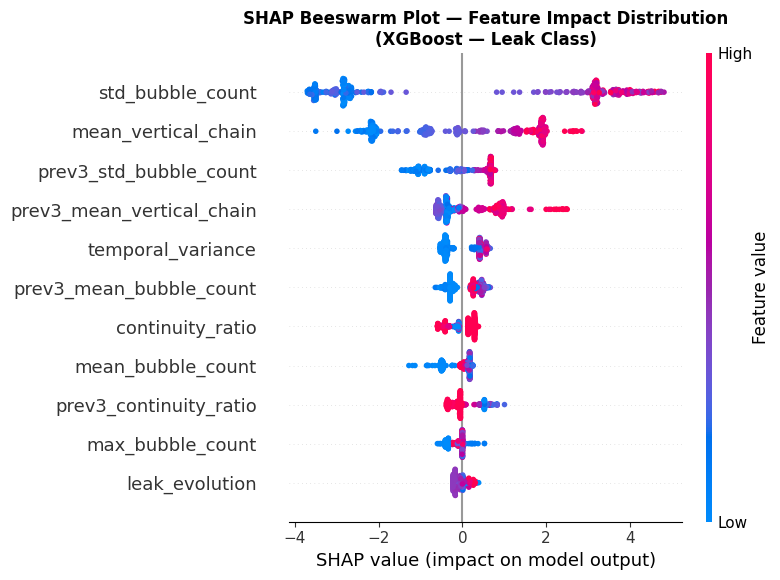

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/shap/xgboost_shap_beeswarm_leak_class.png


In [19]:
# ============================================================
# Plot SHAP beeswarm for leak class
# ============================================================

plt.figure(figsize=(8, 5))

shap.summary_plot(
    shap_leak,
    X_test_shap,
    feature_names=ALL_FEATURES,
    show=False,
)

plt.title(
    "SHAP Beeswarm Plot — Feature Impact Distribution\n"
    "(XGBoost — Leak Class)",
    fontsize=12,
    fontweight="bold",
)

plt.tight_layout()

fig_path = SHAP_DIR / "xgboost_shap_beeswarm_leak_class.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [20]:
# ============================================================
# Export SHAP summary table
# ============================================================

actual_non_leak = test_info["label"].values == 0
actual_leak = test_info["label"].values == 1

shap_bar_df = pd.DataFrame({
    "Feature": ALL_FEATURES,
    "Mean |SHAP| Non-Leak": np.abs(shap_non_leak[actual_non_leak]).mean(axis=0),
    "Mean |SHAP| Leak": np.abs(shap_leak[actual_leak]).mean(axis=0),
})

shap_bar_df["Mean |SHAP| Overall"] = (
    shap_bar_df["Mean |SHAP| Non-Leak"] + shap_bar_df["Mean |SHAP| Leak"]
) / 2

shap_bar_df = shap_bar_df.sort_values("Mean |SHAP| Overall", ascending=False)

shap_bar_path = SHAP_DIR / "xgboost_shap_summary_bar_leak_vs_non_leak.csv"
shap_bar_df.round(6).to_csv(shap_bar_path, index=False)

display(shap_bar_df.round(6))

print("Saved:", shap_bar_path)


,Feature,Mean |SHAP| Non-Leak,Mean |SHAP| Leak,Mean |SHAP| Overall
2,std_bubble_count,3.023534,3.353737,3.188635
6,mean_vertical_chain,1.500746,1.636618,1.568682
8,prev3_std_bubble_count,0.690149,0.657300,0.673724
10,prev3_mean_vertical_chain,0.459820,0.763229,0.611525
3,temporal_variance,0.412071,0.438504,0.425287
7,prev3_mean_bubble_count,0.274233,0.432738,0.353486
5,continuity_ratio,0.291484,0.282469,0.286976
0,mean_bubble_count,0.317226,0.166995,0.242110
9,prev3_continuity_ratio,0.341735,0.114822,0.228279
1,max_bubble_count,0.283770,0.033741,0.158756


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/shap/xgboost_shap_summary_bar_leak_vs_non_leak.csv


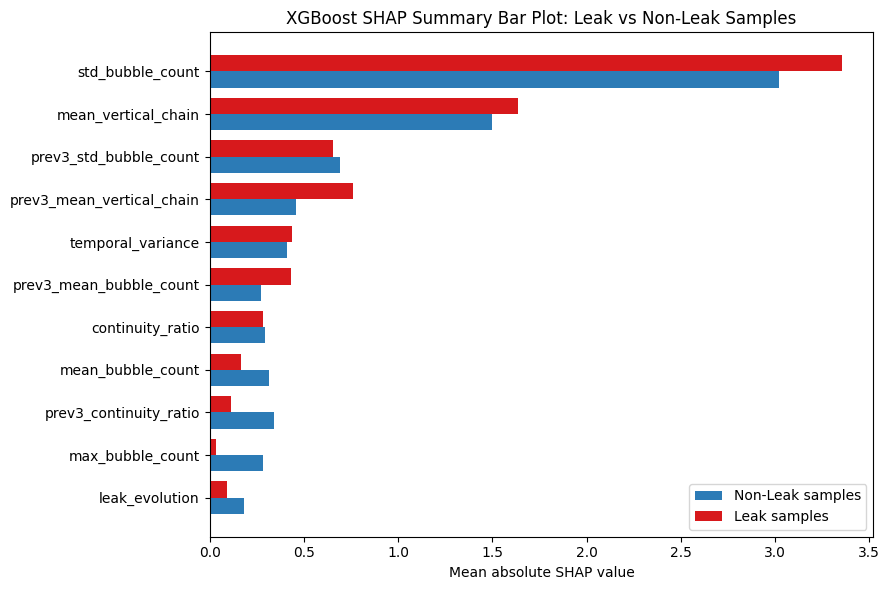

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/shap/xgboost_shap_summary_bar_leak_vs_non_leak.png


In [21]:
# ============================================================
# Plot SHAP summary bar chart
# ============================================================

plot_df = shap_bar_df.sort_values("Mean |SHAP| Overall", ascending=True)

y_pos = np.arange(len(plot_df))
bar_height = 0.38

plt.figure(figsize=(9, 6))

plt.barh(
    y_pos - bar_height / 2,
    plot_df["Mean |SHAP| Non-Leak"],
    height=bar_height,
    label="Non-Leak samples",
    color="#2C7BB6",
)

plt.barh(
    y_pos + bar_height / 2,
    plot_df["Mean |SHAP| Leak"],
    height=bar_height,
    label="Leak samples",
    color="#D7191C",
)

plt.yticks(y_pos, plot_df["Feature"])
plt.xlabel("Mean absolute SHAP value")
plt.title("XGBoost SHAP Summary Bar Plot: Leak vs Non-Leak Samples")
plt.legend()
plt.tight_layout()

fig_path = SHAP_DIR / "xgboost_shap_summary_bar_leak_vs_non_leak.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)


In [22]:
# ============================================================
# Select representative samples for SHAP explanations
# ============================================================

test_info["prediction_type"] = np.where(
    (test_info["label"] == 1) & (test_info["predicted_label"] == 1), "TP",
    np.where(
        (test_info["label"] == 0) & (test_info["predicted_label"] == 0), "TN",
        np.where(
            (test_info["label"] == 0) & (test_info["predicted_label"] == 1), "FP",
            "FN"
        )
    )
)

tp_cases = test_info[test_info["prediction_type"] == "TP"]
tn_cases = test_info[test_info["prediction_type"] == "TN"]

leak_example_idx = int(tp_cases.sort_values("leak_probability", ascending=False).index[0])
non_leak_example_idx = int(tn_cases.sort_values("leak_probability", ascending=True).index[0])

example_columns = [
    "sample_id",
    "source_video_id",
    "window_id",
    "time_sec",
    "condition_id",
    "data_group",
    "g",
    "psi",
    "label",
    "predicted_label",
    "leak_probability",
    "prediction_type",
]
example_columns = [c for c in example_columns if c in test_info.columns]

example_table = test_info.loc[
    [non_leak_example_idx, leak_example_idx],
    example_columns,
]

example_table.to_csv(SHAP_DIR / "xgboost_representative_shap_examples.csv", index=False)

display(example_table)


,sample_id,source_video_id,window_id,condition_id,data_group,g,psi,label,predicted_label,leak_probability,prediction_type
353,NL_G20_500UL_V002_W0022,NL_G20_500UL_V002,22,G20_500UL,few_non_leak,20,0,0,0,0.000239,TN
84,L_G16_PSI14_V001_W0015,L_G16_PSI14_V001,15,G16_PSI14,leak,16,14,1,1,0.999685,TP


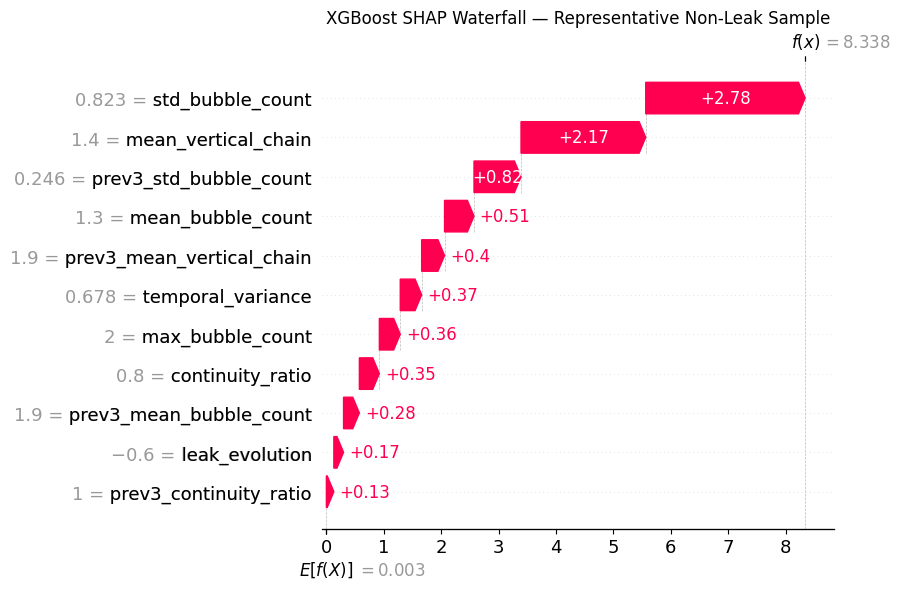

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/shap/xgboost_shap_waterfall_representative_non_leak.png


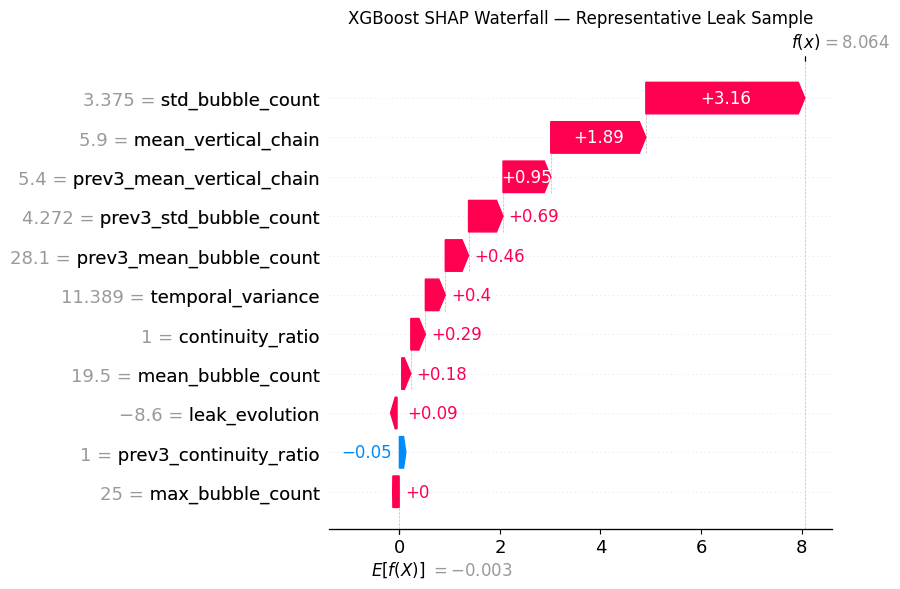

Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/shap/xgboost_shap_waterfall_representative_leak.png


In [23]:
# ============================================================
# Save SHAP waterfall plots
# ============================================================

def make_explanation(sample_index, class_name):
    if class_name == "leak":
        values = shap_leak[sample_index]
        base_value = base_leak
    elif class_name == "non_leak":
        values = shap_non_leak[sample_index]
        base_value = base_non_leak
    else:
        raise ValueError("class_name must be 'leak' or 'non_leak'")

    return shap.Explanation(
        values=values,
        base_values=base_value,
        data=X_test_shap.iloc[sample_index].values,
        feature_names=ALL_FEATURES,
    )

def save_waterfall(sample_index, class_name, title, filename):
    explanation = make_explanation(sample_index, class_name)

    shap.plots.waterfall(explanation, max_display=11, show=False)

    fig = plt.gcf()
    fig.set_size_inches(9, 6)
    plt.title(title)
    plt.tight_layout()

    path = SHAP_DIR / filename
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", path)


save_waterfall(
    sample_index=non_leak_example_idx,
    class_name="non_leak",
    title="XGBoost SHAP Waterfall — Representative Non-Leak Sample",
    filename="xgboost_shap_waterfall_representative_non_leak.png",
)

save_waterfall(
    sample_index=leak_example_idx,
    class_name="leak",
    title="XGBoost SHAP Waterfall — Representative Leak Sample",
    filename="xgboost_shap_waterfall_representative_leak.png",
)


<Figure size 1200x300 with 0 Axes>

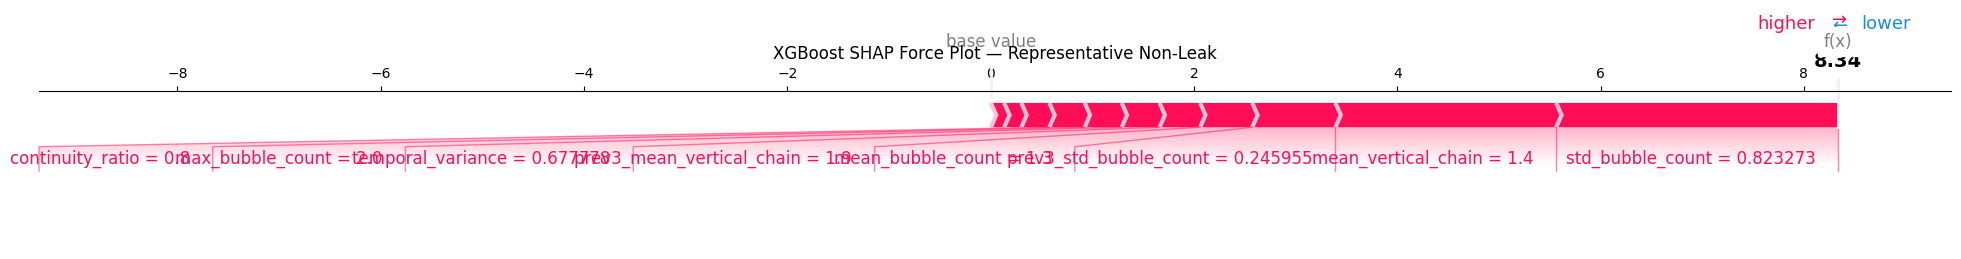

Saved static PNG: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/shap/xgboost_shap_force_representative_non_leak.png


<Figure size 1200x300 with 0 Axes>

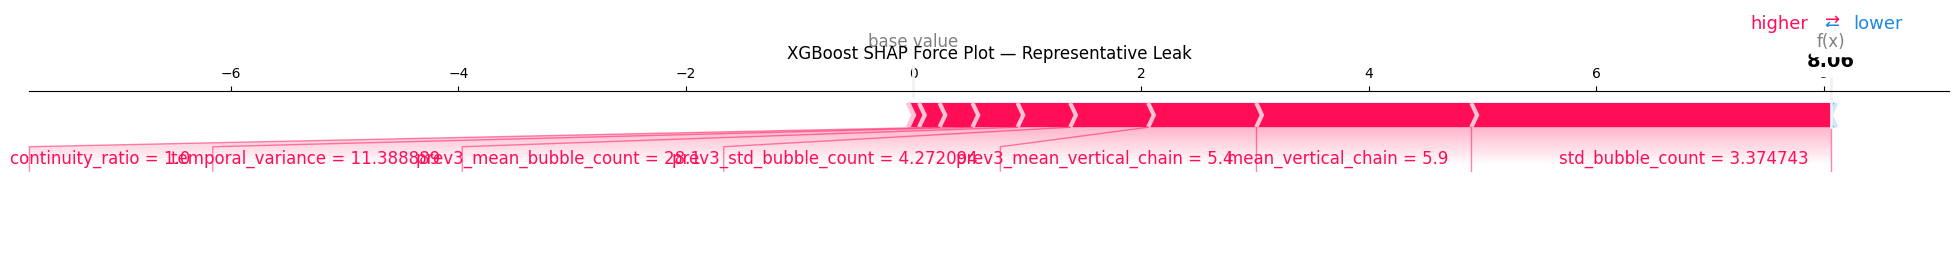

Saved static PNG: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/shap/xgboost_shap_force_representative_leak.png


In [24]:
# ============================================================
# Save static SHAP force plots
# ============================================================

def save_force_plot(sample_index, class_name, title, filename_prefix):
    if class_name == "leak":
        values = shap_leak[sample_index]
        base_value = base_leak
    elif class_name == "non_leak":
        values = shap_non_leak[sample_index]
        base_value = base_non_leak
    else:
        raise ValueError("class_name must be 'leak' or 'non_leak'")

    sample_features = X_test_shap.iloc[sample_index]

    plt.figure(figsize=(12, 3))

    shap.force_plot(
        base_value,
        values,
        sample_features,
        feature_names=ALL_FEATURES,
        matplotlib=True,
        show=False,
    )

    plt.title(title)
    plt.tight_layout()

    png_path = SHAP_DIR / f"{filename_prefix}.png"
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved static PNG:", png_path)


save_force_plot(
    sample_index=non_leak_example_idx,
    class_name="non_leak",
    title="XGBoost SHAP Force Plot — Representative Non-Leak",
    filename_prefix="xgboost_shap_force_representative_non_leak",
)

save_force_plot(
    sample_index=leak_example_idx,
    class_name="leak",
    title="XGBoost SHAP Force Plot — Representative Leak",
    filename_prefix="xgboost_shap_force_representative_leak",
)


In [25]:
# ============================================================
# Export failure-case analysis table
# ============================================================

failure_cases = test_info[test_info["prediction_type"].isin(["FP", "FN"])].copy()

failure_cases = failure_cases.sort_values("leak_probability", ascending=False)

failure_path = SHAP_DIR / "xgboost_failure_cases.csv"
failure_cases.to_csv(failure_path, index=False)

print("Prediction type counts:")
display(test_info["prediction_type"].value_counts().reset_index().rename(
    columns={"index": "Prediction Type", "prediction_type": "Count"}
))

print("\nFailure cases:")
display(failure_cases)

print("Saved:", failure_path)


Prediction type counts:


,Count,count
0,TP,247
1,TN,241
2,FN,6
3,FP,1



Failure cases:


,sample_id,source_video_id,window_id,label,predicted_label,leak_probability,condition_id,data_group,g,psi,n_windows,n_label_0,n_label_1,prediction_type
251,L_G24_PSI10_V001_W0047,L_G24_PSI10_V001,47,0,1,0.922361,G24_PSI10,leak,24,10,46,4,42,FP
44,L_G14_PSI05_V001_W0004,L_G14_PSI05_V001,4,1,0,0.466440,G14_PSI05,leak,14,5,30,5,25,FN
254,L_G24_PSI30_V001_W0004,L_G24_PSI30_V001,4,1,0,0.449843,G24_PSI30,leak,24,30,45,1,44,FN
250,L_G24_PSI10_V001_W0046,L_G24_PSI10_V001,46,1,0,0.377801,G24_PSI10,leak,24,10,46,4,42,FN
118,L_G16_PSI22_V001_W0017,L_G16_PSI22_V001,17,1,0,0.347042,G16_PSI22,leak,16,22,26,7,19,FN
138,L_G18_PSI26_V001_W0013,L_G18_PSI26_V001,13,1,0,0.337606,G18_PSI26,leak,18,26,24,6,18,FN
5,L_G12_PSI05_V001_W0005,L_G12_PSI05_V001,5,1,0,0.249757,G12_PSI05,leak,12,5,40,8,32,FN


Saved: /content/TUBLEX-Bubble-Plume-Analysis/results/xgboost_baseline/shap/xgboost_failure_cases.csv


## Conclusion

This notebook trained and evaluated an XGBoost classifier on the TUBLEX bubble plume descriptor dataset.

The ablation study shows that density-only features provide a useful baseline, while temporal and structural plume descriptors improve classification performance. The final XGBoost baseline uses the same 11 TUBLEX descriptors as the selected Random Forest model and is evaluated using the same video-level split.

SHAP analysis provides global and sample-level interpretation for the XGBoost baseline. Experimental metadata is intentionally excluded from model training and retained only for traceability, reporting, and leakage checking.
